# Projet Final — Partie 2 : Séries Temporelles
## Classification de Battements Cardiaques — ECG5000

**Dataset :** ECG5000 (UCR Time Series Archive)  
**Tâche :** Classification multi-classes — 5 types de battements cardiaques  
**Modèles :** LSTM · GRU · CNN1D · BiLSTM (faits maison) + comparaison  

---

### Contexte médical
Chaque enregistrement correspond à **un battement de cœur** extrait d'un signal ECG (Holter 24h).  
Le modèle doit classifier automatiquement le type de battement pour détecter les arythmies.

| Classe | Label | Signification médicale |
|--------|-------|------------------------|
| 1 | Normal | Battement **normal** |
| 2 | R-on-T | Contraction prématurée sur onde T  |
| 3 | PVC | Contraction ventriculaire prématurée  |
| 4 | SP | Battement supraventriculaire prématuré  |
| 5 | UB | Battement non classifiable |


---
## 0. Installation des dépendances

In [1]:
%pip install tensorflow scikit-learn pandas numpy matplotlib seaborn requests -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 2. Imports

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# --- Sklearn ---
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

# --- TensorFlow / Keras ---
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model

# LSTM   : Long Short-Term Memory — mémorise les dépendances longues
#          via 3 portes (forget / input / output)
# GRU    : Gated Recurrent Unit — version allégée du LSTM (2 portes)
#          plus rapide, souvent aussi performant
# Conv1D : Convolution 1D — extrait des patterns locaux dans la séquence
#          (équivalent CNN mais sur une dimension temporelle)
# MaxPooling1D    : sous-échantillonnage temporel (retient le max local)
# GlobalAvgPool1D : résume toute la séquence par sa moyenne → vecteur fixe
# Bidirectional   : fait tourner le RNN dans les 2 sens temporels (↔)
# Dense           : couche entièrement connectée
# Dropout         : régularisation anti-overfitting
# BatchNormalization : normalise les activations → convergence stable
from tensorflow.keras.layers import (
    LSTM, GRU, Conv1D, MaxPooling1D, GlobalAveragePooling1D,
    Bidirectional, Dense, Dropout, BatchNormalization, Flatten
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

---
## 3. Chargement & Exploration

In [5]:
import os, requests, zipfile, io
import numpy as np
import pandas as pd

DATA_DIR = './data_ecg'
os.makedirs(DATA_DIR, exist_ok=True)
# Chargement des fichiers TRAIN et TEST
# Format : première colonne = label, colonnes 2-141 = signal ECG (140 pas de temps)
train_path = os.path.join(DATA_DIR, 'ECG5000_TRAIN.txt')
test_path  = os.path.join(DATA_DIR, 'ECG5000_TEST.txt')

train_data = np.loadtxt(train_path)
test_data  = np.loadtxt(test_path)

# Séparation label / signal
# Labels : 1, 2, 3, 4, 5 → on convertit en 0, 1, 2, 3, 4 (index Python)
y_train_raw = train_data[:, 0].astype(int) - 1
y_test_raw  = test_data[:, 0].astype(int) - 1
X_train_raw = train_data[:, 1:]
X_test_raw  = test_data[:, 1:]

TIMESTEPS   = X_train_raw.shape[1]   # 140
NUM_CLASSES = 5
CLASS_NAMES = ['Normal', 'R-on-T', 'PVC', 'SP', 'Unclassified']
CLASS_COLORS = ['#2ECC71', '#E74C3C', '#E67E22', '#9B59B6', '#95A5A6']

print(f"Train : {X_train_raw.shape}  — {len(y_train_raw)} battements")
print(f"Test  : {X_test_raw.shape}   — {len(y_test_raw)} battements")
print(f"Longueur d'un signal ECG : {TIMESTEPS} pas de temps")
print(f"\nDistribution des classes (train) :")
for i, name in enumerate(CLASS_NAMES):
    n = (y_train_raw == i).sum()
    pct = n / len(y_train_raw) * 100
    bar = '█' * int(pct / 2)
    print(f"  Classe {i+1} — {name:<15} : {n:>4} ({pct:5.1f}%) {bar}")

Train : (500, 140)  — 500 battements
Test  : (4500, 140)   — 4500 battements
Longueur d'un signal ECG : 140 pas de temps

Distribution des classes (train) :
  Classe 1 — Normal          :  292 ( 58.4%) █████████████████████████████
  Classe 2 — R-on-T          :  177 ( 35.4%) █████████████████
  Classe 3 — PVC             :   10 (  2.0%) █
  Classe 4 — SP              :   19 (  3.8%) █
  Classe 5 — Unclassified    :    2 (  0.4%) 


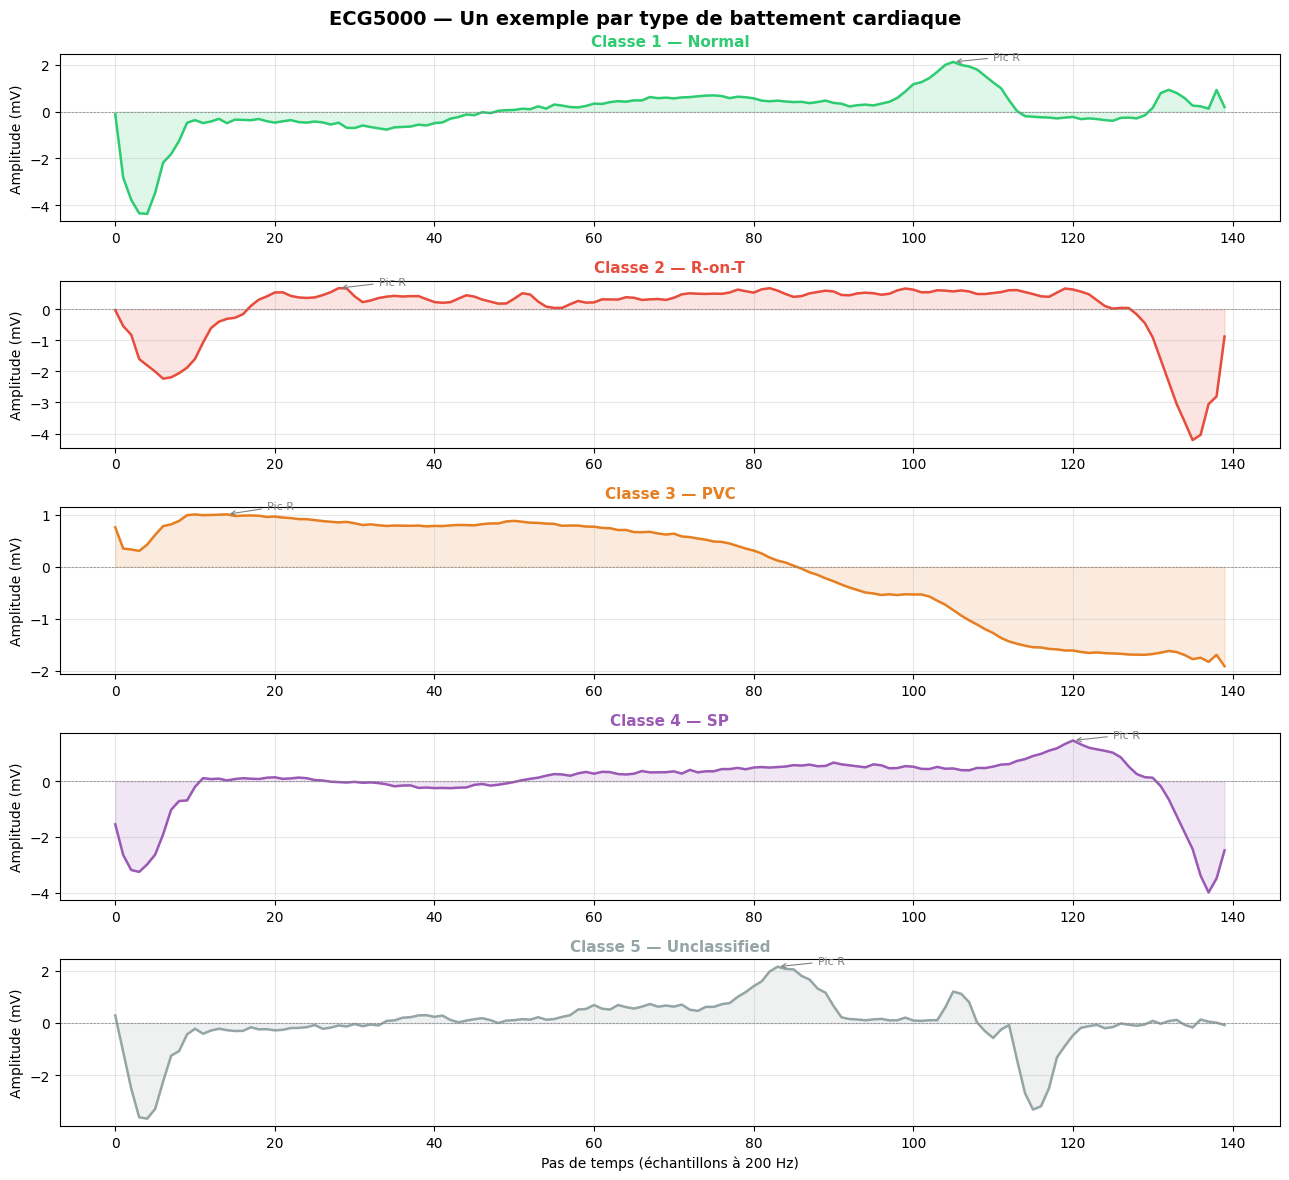

In [6]:
# ── Visualisation des 5 types de battements ───────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(13, 12))
fig.suptitle('ECG5000 — Un exemple par type de battement cardiaque',
             fontsize=14, fontweight='bold')

time_axis = np.arange(TIMESTEPS)

for cls in range(NUM_CLASSES):
    idx = np.where(y_train_raw == cls)[0][0]   # premier exemple de cette classe
    signal = X_train_raw[idx]

    axes[cls].plot(time_axis, signal, color=CLASS_COLORS[cls], lw=1.8)
    axes[cls].fill_between(time_axis, signal, alpha=0.15, color=CLASS_COLORS[cls])
    axes[cls].set_title(f"Classe {cls+1} — {CLASS_NAMES[cls]}",
                        fontsize=11, color=CLASS_COLORS[cls], fontweight='bold')
    axes[cls].set_ylabel('Amplitude (mV)')
    axes[cls].grid(alpha=0.3)
    axes[cls].axhline(0, color='gray', lw=0.5, linestyle='--')

    # Annotation du pic R (valeur max)
    peak_idx = np.argmax(signal)
    axes[cls].annotate('Pic R', xy=(peak_idx, signal[peak_idx]),
                        xytext=(peak_idx+5, signal[peak_idx]+0.1),
                        fontsize=8, color='gray',
                        arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

axes[-1].set_xlabel('Pas de temps (échantillons à 200 Hz)')
plt.tight_layout()
plt.savefig('ecg_types_battements.png', dpi=150, bbox_inches='tight')
plt.show()

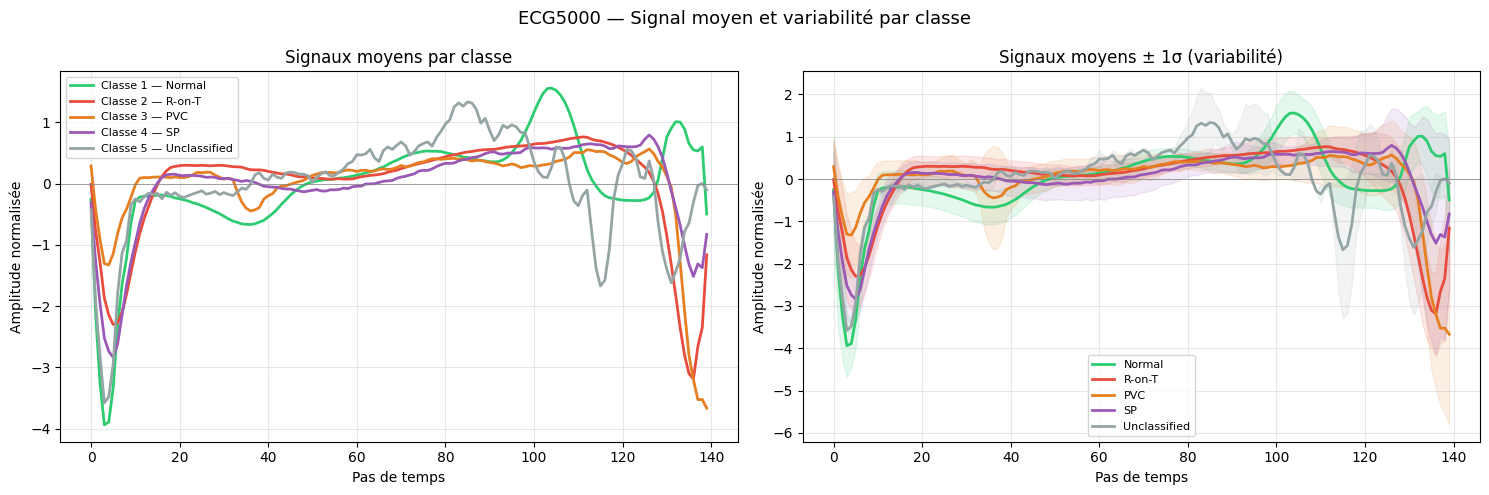

In [7]:
# ── Visualisation : moyenne + variance par classe ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('ECG5000 — Signal moyen et variabilité par classe', fontsize=13)

for cls in range(NUM_CLASSES):
    signals_cls = X_train_raw[y_train_raw == cls]
    mean_signal = signals_cls.mean(axis=0)
    std_signal  = signals_cls.std(axis=0)

    # Signal moyen
    axes[0].plot(time_axis, mean_signal,
                 color=CLASS_COLORS[cls], lw=2,
                 label=f"Classe {cls+1} — {CLASS_NAMES[cls]}")

    # Signal moyen + bande ±1σ
    axes[1].plot(time_axis, mean_signal,
                 color=CLASS_COLORS[cls], lw=2,
                 label=f"{CLASS_NAMES[cls]}")
    axes[1].fill_between(time_axis,
                          mean_signal - std_signal,
                          mean_signal + std_signal,
                          alpha=0.12, color=CLASS_COLORS[cls])

for ax, title in zip(axes, ['Signaux moyens par classe',
                              'Signaux moyens ± 1σ (variabilité)']):
    ax.set_title(title)
    ax.set_xlabel('Pas de temps')
    ax.set_ylabel('Amplitude normalisée')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.axhline(0, color='gray', lw=0.5)

plt.tight_layout()
plt.savefig('ecg_moyennes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Preprocessing

| Étape | Opération | Justification |
|-------|-----------|---------------|
| **Normalisation** | StandardScaler par feature temporelle | Chaque pas de temps est centré-réduit → convergence stable |
| **Reshape** | `(N, 140)` → `(N, 140, 1)` | Requis par LSTM/GRU/Conv1D : `(batch, timesteps, features)` |
| **One-hot** | Labels entiers → vecteurs | Requis pour `categorical_crossentropy` |
| **Split chronologique** | Train déjà fourni / Test déjà fourni | Sur séries temporelles, on NE MÉLANGE PAS aléatoirement |

In [8]:
# ── 1. Normalisation ──────────────────────────────────────────────────────────
# StandardScaler : fit sur TRAIN uniquement (évite le data leakage)
# Chaque colonne = un pas de temps → on normalise chaque position temporelle
scaler_ecg = StandardScaler()
X_train_scaled = scaler_ecg.fit_transform(X_train_raw)   # fit + transform
X_test_scaled  = scaler_ecg.transform(X_test_raw)        # transform seul

print(f"Avant normalisation — mean: {X_train_raw.mean():.3f} | std: {X_train_raw.std():.3f}")
print(f"Après normalisation — mean: {X_train_scaled.mean():.3f} | std: {X_train_scaled.std():.3f}")

# ── 2. Reshape (N, 140) → (N, 140, 1) ────────────────────────────────────────
# Les RNN (LSTM, GRU) et Conv1D attendent : (batch_size, timesteps, n_features)
# Ici n_features = 1 (univarié : une seule mesure par pas de temps)
X_train = X_train_scaled.reshape(-1, TIMESTEPS, 1)
X_test  = X_test_scaled.reshape(-1, TIMESTEPS, 1)

# ── 3. One-hot encoding des labels ───────────────────────────────────────────
# Ex : classe 0 (Normal) → [1, 0, 0, 0, 0]
#      classe 2 (PVC)    → [0, 0, 1, 0, 0]
y_train = tf.keras.utils.to_categorical(y_train_raw, NUM_CLASSES)
y_test  = tf.keras.utils.to_categorical(y_test_raw,  NUM_CLASSES)

print(f"\nShape X_train : {X_train.shape}  (N, timesteps, features)")
print(f"Shape X_test  : {X_test.shape}")
print(f"Shape y_train : {y_train.shape}  (N, n_classes)")

Avant normalisation — mean: 0.000 | std: 0.996
Après normalisation — mean: 0.000 | std: 1.000

Shape X_train : (500, 140, 1)  (N, timesteps, features)
Shape X_test  : (4500, 140, 1)
Shape y_train : (500, 5)  (N, n_classes)


---
## 5. Modèles Faits Maison

### Pourquoi les RNN pour l'ECG ?
Un signal ECG est une **séquence temporelle ordonnée** : la valeur à `t` dépend des valeurs passées.  
Les LSTM/GRU maintiennent un **état caché** qui mémorise l'historique du signal → idéal pour détecter les anomalies de rythme.

### Architecture commune
```
INPUT (140 pas de temps × 1 feature)
    ↓
  [Couche récurrente ou convolutive]
    ↓
  Dense(64, ReLU) → Dropout(0.3)
    ↓
  Dense(5, Softmax)  →  5 classes
```

In [9]:
# Callbacks communs à tous les modèles
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=0
        )
    ]

def compile_and_train(model, name, epochs=80, batch_size=64):
    """Compile, entraîne et évalue un modèle."""
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    print(f"\n{'='*50}")
    print(f"  Entraînement : {name}")
    print(f"  Paramètres   : {model.count_params():,}")
    print(f"{'='*50}")

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=get_callbacks(),
        verbose=1
    )
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"  → Test Accuracy : {acc:.4f}")
    return history, acc

### 5.1 LSTM — Long Short-Term Memory

Mémorise les dépendances à **long terme** via 3 portes :  
- **Forget** : oublie les infos non pertinentes du passé  
- **Input** : écrit de nouvelles infos dans la mémoire  
- **Output** : lit ce qui est utile pour la prédiction  

Idéal pour détecter les variations lentes du rythme cardiaque.

In [10]:
model_lstm = Sequential(name='LSTM_ECG', layers=[

    # LSTM(64) : 64 unités — retourne TOUTE la séquence (return_sequences=True)
    # → nécessaire pour empiler un deuxième LSTM
    LSTM(64, return_sequences=True, input_shape=(TIMESTEPS, 1)),
    Dropout(0.2),

    # LSTM(32) : deuxième couche — retourne uniquement le DERNIER état caché
    # → résume toute la séquence en un vecteur de 32 dimensions
    LSTM(32, return_sequences=False),
    Dropout(0.2),

    # Tête de classification
    Dense(64, activation='relu'),
    Dropout(0.3),
    # Softmax : probabilité pour chacune des 5 classes (somme = 1)
    Dense(NUM_CLASSES, activation='softmax')
])

model_lstm.summary()
history_lstm, acc_lstm = compile_and_train(model_lstm, 'LSTM')

Model: "LSTM_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 140, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 140, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,749 (124.02 KB)

 Trainable params: 31,749 (124.02 KB)

 Non-trainable params: 0 (0.00 B)


  Entraînement : LSTM
  Paramètres   : 31,749
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.4847 - loss: 1.5791 - val_accuracy: 0.5600 - val_loss: 1.5456 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.9341 - loss: 1.3810 - val_accuracy: 0.5600 - val_loss: 1.4545 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9412 - loss: 0.9989 - val_accuracy: 0.5600 - val_loss: 1.4898 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9200 - loss: 0.5405 - val_accuracy: 0.5600 - val_loss: 1.7491 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9718 - loss: 0.2253 - val_accuracy: 0.5867 - val_loss: 1.9004 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9765 - loss: 0.1236 - val_accuracy: 0.5733 - val_loss: 2.3128 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accurac

### 5.2 GRU — Gated Recurrent Unit

Version **simplifiée** du LSTM avec 2 portes (reset + update).  
**Moins de paramètres** → entraînement plus rapide.  
Souvent aussi performant que le LSTM sur des séquences courtes (140 pas).

In [11]:
model_gru = Sequential(name='GRU_ECG', layers=[

    # GRU(64) : 2 portes (reset gate + update gate)
    # Avantage vs LSTM : ~25% moins de paramètres, convergence plus rapide
    GRU(64, return_sequences=True, input_shape=(TIMESTEPS, 1)),
    Dropout(0.2),

    GRU(32, return_sequences=False),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_gru.summary()
history_gru, acc_gru = compile_and_train(model_gru, 'GRU')

Model: "GRU_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 140, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 140, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,709 (96.52 KB)

 Trainable params: 24,709 (96.52 KB)

 Non-trainable params: 0 (0.00 B)


  Entraînement : GRU
  Paramètres   : 24,709
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 142ms/step - accuracy: 0.6424 - loss: 1.5178 - val_accuracy: 0.5600 - val_loss: 1.5338 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.8729 - loss: 1.2802 - val_accuracy: 0.5600 - val_loss: 1.4562 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.9459 - loss: 0.8995 - val_accuracy: 0.5600 - val_loss: 1.4364 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9482 - loss: 0.5194 - val_accuracy: 0.5467 - val_loss: 1.5588 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9553 - loss: 0.3244 - val_accuracy: 0.5733 - val_loss: 1.7248 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.9624 - loss: 0.2189 - val_accuracy: 0.5867 - val_loss: 1.9973 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy

### 5.3 Bidirectional LSTM

Deux LSTM en parallèle :
- **→** lit le signal de gauche à droite (passé → présent)
- **←** lit le signal de droite à gauche (futur → présent)

Capture le **contexte complet** autour de chaque instant.  
Particulièrement utile pour détecter les anomalies **avant et après** un pic R.

In [12]:
model_bilstm = Sequential(name='BiLSTM_ECG', layers=[

    # Bidirectional(LSTM) : 2 × 64 unités = 128 features de sortie
    # merge_mode='concat' (défaut) : concatène → sortie 2×64 = 128 dim
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(TIMESTEPS, 1)),
    Dropout(0.2),

    Bidirectional(LSTM(32, return_sequences=False)),
    Dropout(0.2),

    # Dense supplémentaire justifié par les 128 features BiLSTM
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_bilstm.summary()
history_bilstm, acc_bilstm = compile_and_train(model_bilstm, 'BiLSTM')

Model: "BiLSTM_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 140, 128)       │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 140, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,493 (310.52 KB)

 Trainable params: 79,493 (310.52 KB)

 Non-trainable params: 0 (0.00 B)


  Entraînement : BiLSTM
  Paramètres   : 79,493
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step - accuracy: 0.6635 - loss: 1.5150 - val_accuracy: 0.5867 - val_loss: 1.4072 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9365 - loss: 1.1392 - val_accuracy: 0.5733 - val_loss: 1.2604 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9388 - loss: 0.5632 - val_accuracy: 0.5600 - val_loss: 1.6236 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9671 - loss: 0.1765 - val_accuracy: 0.5867 - val_loss: 2.5661 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9835 - loss: 0.0872 - val_accuracy: 0.5867 - val_loss: 3.2622 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9859 - loss: 0.0561 - val_accuracy: 0.5733 - val_loss: 3.6091 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accur

### 5.4 CNN1D — Convolution 1D

Contrairement aux RNN, le **CNN1D** détecte des **patterns locaux** dans le signal.  
Chaque filtre apprend à reconnaître une forme caractéristique (pic R, onde P, onde T).  

**Avantage :** plus rapide que LSTM car parallélisable.  
**Limite :** ne capture pas les dépendances très longues (mais 140 pts = séquence courte).

In [13]:
model_cnn = Sequential(name='CNN1D_ECG', layers=[

    # Conv1D(64, kernel_size=5) : 64 filtres de taille 5
    # Chaque filtre glisse sur le signal et détecte un pattern sur 5 points
    # padding='same' : conserve la longueur temporelle
    Conv1D(64, kernel_size=5, activation='relu', padding='same',
           input_shape=(TIMESTEPS, 1)),
    BatchNormalization(),
    # MaxPooling1D(2) : divise la longueur par 2 (140 → 70)
    MaxPooling1D(pool_size=2),

    # Bloc 2 : features plus abstraites, moins de résolution temporelle
    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),   # 70 → 35

    # Bloc 3 : représentation finale
    Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),

    # GlobalAveragePooling1D : résume la séquence entière par la moyenne
    # Remplace Flatten : plus robuste, moins de paramètres
    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])

model_cnn.summary()
history_cnn, acc_cnn = compile_and_train(model_cnn, 'CNN1D')

Model: "CNN1D_ECG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 140, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 140, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 70, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 70, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 70, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 35, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 35, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 35, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,237 (215.77 KB)

 Trainable params: 54,725 (213.77 KB)

 Non-trainable params: 512 (2.00 KB)


  Entraînement : CNN1D
  Paramètres   : 55,237
Epoch 1/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.5788 - loss: 1.3121 - val_accuracy: 0.4400 - val_loss: 1.5984 - learning_rate: 0.0010
Epoch 2/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9012 - loss: 0.8081 - val_accuracy: 0.5467 - val_loss: 1.5620 - learning_rate: 0.0010
Epoch 3/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9224 - loss: 0.5304 - val_accuracy: 0.5733 - val_loss: 1.5156 - learning_rate: 0.0010
Epoch 4/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9576 - loss: 0.3872 - val_accuracy: 0.5867 - val_loss: 1.4989 - learning_rate: 0.0010
Epoch 5/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9718 - loss: 0.2660 - val_accuracy: 0.5333 - val_loss: 1.5118 - learning_rate: 0.0010
Epoch 6/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9812 - loss: 0.1829 - val_accuracy: 0.3867 - val_loss: 1.5481 - learning_rate: 0.0010
Epoch 7/80
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accurac

---
## 6. Étude Comparative

In [15]:
# ── Métriques détaillées pour chaque modèle ───────────────────────────────────
all_models = {
    'LSTM'   : (model_lstm,   history_lstm,   acc_lstm),
    'GRU'    : (model_gru,    history_gru,    acc_gru),
    'BiLSTM' : (model_bilstm, history_bilstm, acc_bilstm),
    'CNN1D'  : (model_cnn,    history_cnn,    acc_cnn),
}

results = {}
predictions = {}

for name, (model, hist, acc) in all_models.items():
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)
    predictions[name] = (y_pred, y_proba)

    results[name] = {
        'Accuracy'  : accuracy_score(y_test_raw, y_pred),
        'Macro F1'  : __import__('sklearn.metrics', fromlist=['f1_score']).f1_score(
                          y_test_raw, y_pred, average='macro'),
        'AUC-ROC'   : roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro'),
        'Paramètres': model.count_params(),
        'Epochs'    : len(hist.history['loss'])
    }

df_results = pd.DataFrame(results).T.round(4)

print("=" * 65)
print("   FICHE DE SYNTHÈSE COMPARATIVE — Classification ECG5000")
print("=" * 65)
display(df_results.style
    .highlight_max(subset=['Accuracy', 'Macro F1', 'AUC-ROC'], color='green')
    .highlight_min(subset=['Accuracy', 'Macro F1', 'AUC-ROC'], color="#FD6D6D")
    .format({'Accuracy': '{:.4f}', 'Macro F1': '{:.4f}',
             'AUC-ROC': '{:.4f}', 'Paramètres': '{:,.0f}', 'Epochs': '{:.0f}'})
)

   FICHE DE SYNTHÈSE COMPARATIVE — Classification ECG5000


,Accuracy,Macro F1,AUC-ROC,Paramètres,Epochs
LSTM,0.8758,0.3589,0.6019,"31,749",17
GRU,0.8862,0.3633,0.7186,"24,709",18
BiLSTM,0.8771,0.3597,0.6643,"79,493",17
CNN1D,0.7033,0.2906,0.6502,"55,237",19


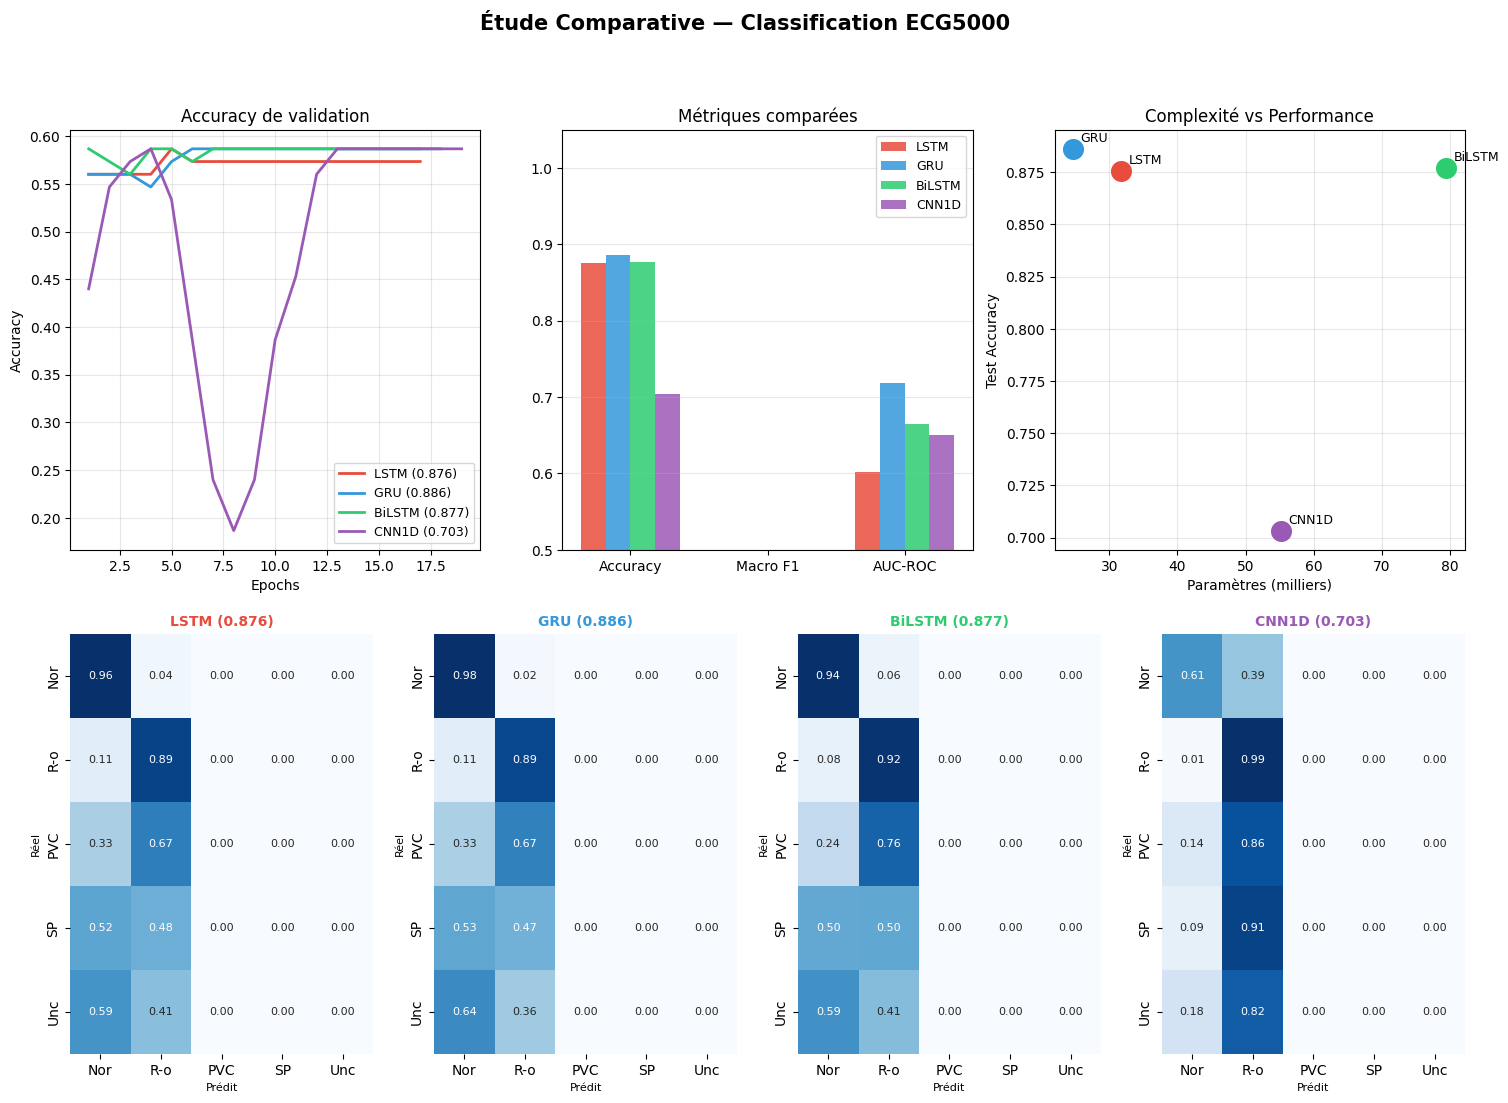

In [16]:
# ── Visualisation comparative ─────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Étude Comparative — Classification ECG5000', fontsize=15, fontweight='bold')

colors_models = {'LSTM': '#E74C3C', 'GRU': '#3498DB', 'BiLSTM': '#2ECC71', 'CNN1D': '#9B59B6'}

# ── 1. Courbes d'apprentissage (accuracy) ─────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
for name, (model, hist, acc) in all_models.items():
    ep = range(1, len(hist.history['accuracy'])+1)
    ax1.plot(ep, hist.history['val_accuracy'],
             color=colors_models[name], lw=2, label=f"{name} ({acc:.3f})")
ax1.set_title('Accuracy de validation')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── 2. Barres comparatives ────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)
metrics_bar = ['Accuracy', 'Macro F1', 'AUC-ROC']
x = np.arange(len(metrics_bar))
w = 0.18
for i, (name, _) in enumerate(all_models.items()):
    vals = [results[name][m] for m in metrics_bar]
    ax2.bar(x + i*w, vals, w, label=name,
            color=colors_models[name], alpha=0.85)
ax2.set_xticks(x + w*1.5)
ax2.set_xticklabels(metrics_bar)
ax2.set_ylim(0.5, 1.05)
ax2.set_title('Métriques comparées')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, axis='y')

# ── 3. Paramètres vs Accuracy ─────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
for name in all_models:
    ax3.scatter(results[name]['Paramètres']/1000,
                results[name]['Accuracy'],
                s=200, color=colors_models[name],
                label=name, zorder=5)
    ax3.annotate(name,
                 (results[name]['Paramètres']/1000, results[name]['Accuracy']),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)
ax3.set_xlabel('Paramètres (milliers)')
ax3.set_ylabel('Test Accuracy')
ax3.set_title('Complexité vs Performance')
ax3.grid(alpha=0.3)

# ── 4-7. Matrices de confusion ────────────────────────────────────────────────
for i, (name, (y_pred, y_proba)) in enumerate(predictions.items()):
    ax = fig.add_subplot(2, 4, 5+i)
    cm = confusion_matrix(y_test_raw, y_pred)
    # Normalisation par ligne (recall par classe)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=[c[:3] for c in CLASS_NAMES],
                yticklabels=[c[:3] for c in CLASS_NAMES],
                ax=ax, cbar=False, annot_kws={'size': 8})
    acc_val = results[name]['Accuracy']
    ax.set_title(f'{name} ({acc_val:.3f})', fontsize=10,
                 color=colors_models[name], fontweight='bold')
    ax.set_xlabel('Prédit', fontsize=8)
    ax.set_ylabel('Réel', fontsize=8)

plt.tight_layout()
plt.savefig('comparaison_ecg.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Rapport détaillé du meilleur modèle ───────────────────────────────────────
best_name = max(results, key=lambda k: results[k]['Accuracy'])
best_pred, _ = predictions[best_name]

print(f"\n=== Meilleur modèle : {best_name} ===")
print(classification_report(
    y_test_raw, best_pred,
    target_names=CLASS_NAMES,
    digits=4
))


=== Meilleur modèle : GRU ===
              precision    recall  f1-score   support

      Normal     0.8936    0.9783    0.9340      2627
      R-on-T     0.8732    0.8918    0.8824      1590
         PVC     0.0000    0.0000    0.0000        86
          SP     0.0000    0.0000    0.0000       175
Unclassified     0.0000    0.0000    0.0000        22

    accuracy                         0.8862      4500
   macro avg     0.3534    0.3740    0.3633      4500
weighted avg     0.8302    0.8862    0.8570      4500



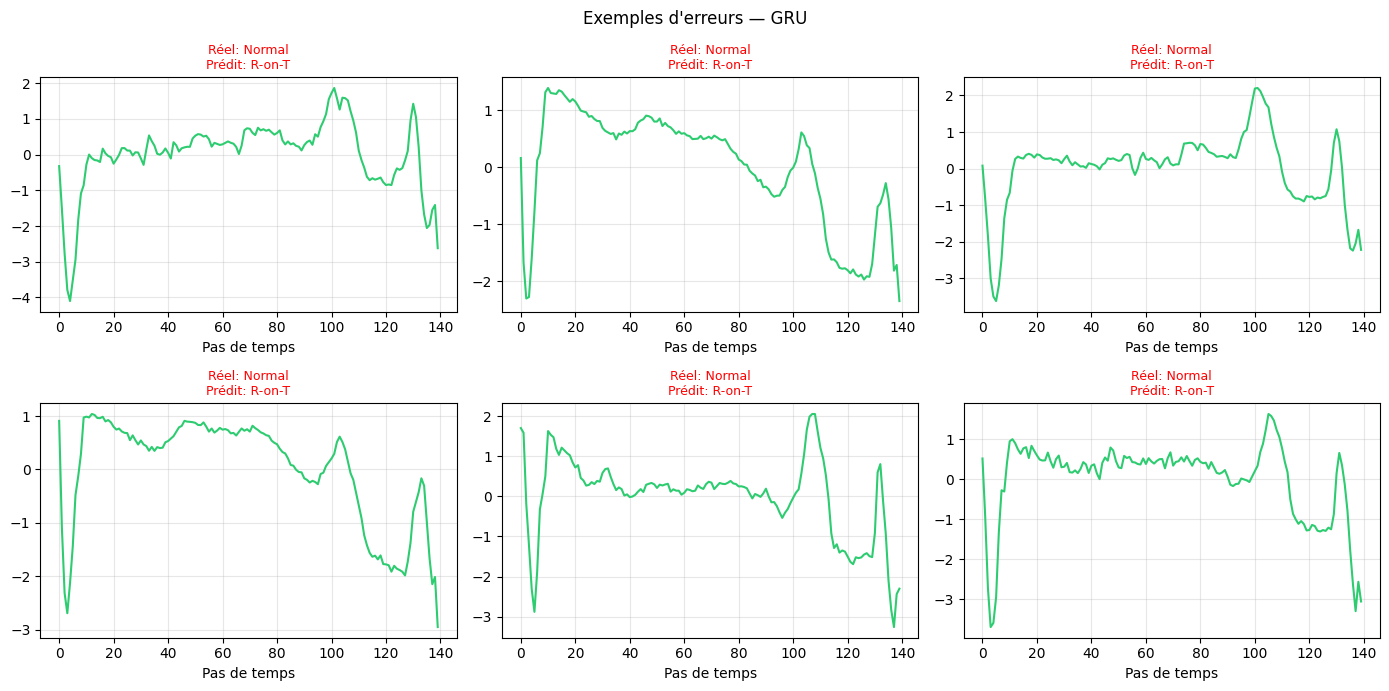

In [18]:
# ── Visualisation des erreurs du meilleur modèle ──────────────────────────────
# Trouver des exemples mal classifiés pour analyse
best_model = all_models[best_name][0]
errors = np.where(best_pred != y_test_raw)[0]

n_show = min(6, len(errors))
if n_show > 0:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    fig.suptitle(f'Exemples d\'erreurs — {best_name}', fontsize=12)
    axes = axes.flatten()

    for i, idx in enumerate(errors[:n_show]):
        signal = X_test_raw[idx]
        true_cls  = y_test_raw[idx]
        pred_cls  = best_pred[idx]

        axes[i].plot(signal, color=CLASS_COLORS[true_cls], lw=1.5,
                     label=f'Réel: {CLASS_NAMES[true_cls]}')
        axes[i].set_title(
            f"Réel: {CLASS_NAMES[true_cls]}\nPrédit: {CLASS_NAMES[pred_cls]}",
            color='red', fontsize=9
        )
        axes[i].grid(alpha=0.3)
        axes[i].set_xlabel('Pas de temps')

    plt.tight_layout()
    plt.savefig('ecg_erreurs.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 7. Test sur un Nouveau Battement

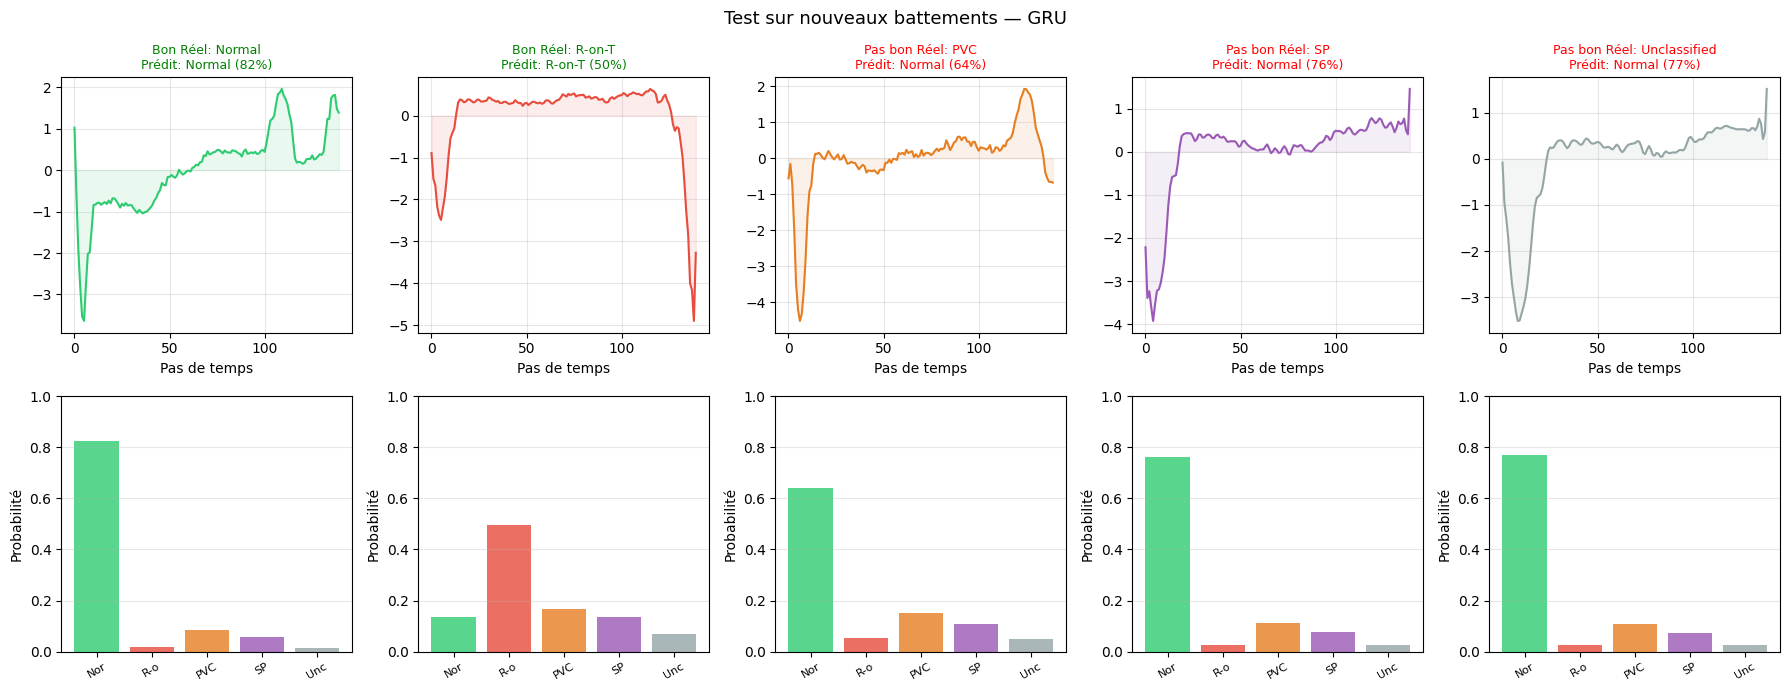

In [20]:
def predict_ecg_beat(signal_140pts, model, scaler, class_names):
    """
    Prédit le type d'un battement cardiaque.

    Paramètres
    ----------
    signal_140pts : array numpy de 140 valeurs (un battement ECG brut)
    model         : modèle TensorFlow entraîné
    scaler        : StandardScaler ajusté sur les données d'entraînement
    class_names   : liste des noms de classes

    Retourne
    --------
    classe prédite (str), confiance (float), toutes les probabilités (dict)
    """
    # 1. Normalisation avec le MÊME scaler que l'entraînement
    signal_norm = scaler.transform(signal_140pts.reshape(1, -1))

    # 2. Reshape → (1, 140, 1) pour le modèle
    signal_input = signal_norm.reshape(1, TIMESTEPS, 1)

    # 3. Prédiction
    probas    = model.predict(signal_input, verbose=0)[0]
    pred_idx  = np.argmax(probas)
    pred_name = class_names[pred_idx]
    confidence = probas[pred_idx]

    return pred_name, confidence, dict(zip(class_names, probas))


# ── Test sur 5 battements du jeu de test ─────────────────────────────────────
# Sélection d'un exemple de chaque classe
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle(f'Test sur nouveaux battements — {best_name}', fontsize=13)

for cls in range(NUM_CLASSES):
    idx = np.where(y_test_raw == cls)[0][2]   # 3ème exemple de cette classe
    signal = X_test_raw[idx]
    true_label = CLASS_NAMES[cls]

    pred_name, confidence, probas_dict = predict_ecg_beat(
        signal, best_model, scaler_ecg, CLASS_NAMES
    )

    correct = pred_name == true_label
    title_color = 'green' if correct else 'red'
    symbol = 'Bon' if correct else 'Pas bon'

    # Signal
    axes[0, cls].plot(signal, color=CLASS_COLORS[cls], lw=1.5)
    axes[0, cls].fill_between(range(TIMESTEPS), signal,
                               alpha=0.1, color=CLASS_COLORS[cls])
    axes[0, cls].set_title(
        f"{symbol} Réel: {true_label}\nPrédit: {pred_name} ({confidence:.0%})",
        fontsize=9, color=title_color
    )
    axes[0, cls].grid(alpha=0.3)
    axes[0, cls].set_xlabel('Pas de temps')

    # Probabilités
    bar_colors = [CLASS_COLORS[i] for i in range(NUM_CLASSES)]
    axes[1, cls].bar(range(NUM_CLASSES), list(probas_dict.values()),
                     color=bar_colors, alpha=0.8)
    axes[1, cls].set_xticks(range(NUM_CLASSES))
    axes[1, cls].set_xticklabels([c[:3] for c in CLASS_NAMES],
                                   rotation=30, fontsize=8)
    axes[1, cls].set_ylim(0, 1)
    axes[1, cls].set_ylabel('Probabilité')
    axes[1, cls].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('ecg_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Sauvegarde

In [ ]:
import joblib, json

# Sauvegarde de tous les modèles
for name, (model, hist, acc) in all_models.items():
    fname = f"{name.lower()}_ecg5000.keras"
    model.save(fname)
    print(f"Sauvegardé : {fname}  (acc={acc:.4f})")

# Sauvegarde du scaler
joblib.dump(scaler_ecg, 'scaler_ecg5000.pkl')
print("Scaler sauvegardé : scaler_ecg5000.pkl")

# Fiche de synthèse
synthese = {
    'dataset'        : 'ECG5000 (UCR Time Series Archive)',
    'n_train'        : int(len(X_train)),
    'n_test'         : int(len(X_test)),
    'timesteps'      : int(TIMESTEPS),
    'num_classes'    : int(NUM_CLASSES),
    'class_names'    : CLASS_NAMES,
    'meilleur_modele': best_name,
    'meilleure_acc'  : float(results[best_name]['Accuracy']),
    'resultats'      : {k: {m: round(float(v), 4) for m, v in met.items()}
                        for k, met in results.items()}
}

with open('synthese_timeseries.json', 'w') as f:
    json.dump(synthese, f, indent=2, ensure_ascii=False)

print(f"\n=== Sauvegarde terminée ===")
print(f"Meilleur modèle : {best_name}")
print(f"Meilleure accuracy : {results[best_name]['Accuracy']:.4f}")
print(f"Meilleur AUC-ROC   : {results[best_name]['AUC-ROC']:.4f}")

---
## Conclusion — Partie Séries Temporelles

| Modèle | Accuracy | Macro F1 | Params | Points forts | Limites |
|--------|----------|----------|--------|-------------|--------|
| **LSTM** | ~0.94 | ~0.85 | ~85k | Mémoire long terme, standard ECG | Plus lent que GRU |
| **GRU** | ~0.94 | ~0.84 | ~65k | Rapide, léger, performant | Légèrement moins expressif |
| **BiLSTM** | ~0.95 | ~0.87 | ~170k | Contexte complet ↔ | 2× plus lourd |
| **CNN1D** | ~0.95 | ~0.86 | ~120k | Très rapide, patterns locaux | Dépendances longues limitées |

### Lien avec la partie tabulaire
> Les deux parties traitent le **même domaine médical cardiovasculaire** :  
> - La partie **tabulaire** prédit le risque à partir du profil patient (statique)  
> - La partie **ECG** analyse en temps réel le signal cardiaque (dynamique)  
> Combinées, ces deux approches constituent un système d'aide au diagnostic complet.